# Experiment 3 — Chọn feature trước khi huấn luyện

Notebook này mở rộng Experiment 2 bằng cách chọn 10 feature có tương quan Pearson lớn nhất với `Diabetes_binary`. Tương quan được tính **chỉ trên tập train** để tránh sử dụng thông tin của validation/test trong bước lựa chọn feature.

## Quy trình thực hiện

1. Đọc và kiểm tra dữ liệu, sau đó tách stratified thành train/validation/test.
2. Tính correlation của từng feature với target trên `X_train` và `y_train`.
3. Xếp hạng theo trị tuyệt đối của correlation và giữ lại 10 feature đầu tiên.
4. Lọc cả ba tập dữ liệu theo cùng `selected_indices`, rồi mới chuẩn hóa bằng thống kê của train.
5. Huấn luyện MLP `10 -> 64 -> 32 -> 1` với learning rate `0.01`.
6. Đánh giá, lưu biểu đồ/model và lưu cả danh sách feature đã chọn để dự đoán dữ liệu mới đúng thứ tự.

## 10 feature được chọn

`GenHlth`, `HighBP`, `HighChol`, `BMI`, `Age`, `DiffWalk`, `Income`, `HeartDiseaseorAttack`, `PhysHlth`, `Education`.

## Cấu hình và kết quả tham khảo

- Seed: `42`; epochs: `50`; batch size: `512`; learning rate: `0.01`.
- Train loss cuối: `0.5075`; validation loss cuối: `0.5166`.
- Accuracy: `0.7434`; precision: `0.7249`; recall: `0.7847`; F1-score: `0.7536`.

Correlation đơn biến chỉ mô tả quan hệ tuyến tính riêng lẻ, không chứng minh quan hệ nhân quả và có thể bỏ qua tương tác giữa các feature. Các cell tiếp theo thể hiện trọn pipeline: chọn feature → xây dựng mạng → huấn luyện → đánh giá → lưu model.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
SEED = 42

np.random.seed(SEED)

DATA_PATH = Path(
    "data/diabetes.csv"
)

MODEL_DIR = Path("models")
FIGURE_DIR = Path("figures")
OUTPUT_DIR = Path("outputs")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Ready.")

Ready.


In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset shape:", df.shape)

df.head()

Dataset shape: (70692, 22)


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,0.0,...,1.0,0.0,3.0,5.0,30.0,0.0,1.0,4.0,6.0,8.0
1,0.0,1.0,1.0,1.0,26.0,1.0,1.0,0.0,0.0,1.0,...,1.0,0.0,3.0,0.0,0.0,0.0,1.0,12.0,6.0,8.0
2,0.0,0.0,0.0,1.0,26.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,1.0,0.0,10.0,0.0,1.0,13.0,6.0,8.0
3,0.0,1.0,1.0,1.0,28.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,3.0,0.0,3.0,0.0,1.0,11.0,6.0,8.0
4,0.0,0.0,0.0,1.0,29.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,8.0,5.0,8.0


In [4]:
print(df.columns.tolist())

['Diabetes_binary', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Diabetes_binary,70692.0,0.500000,0.500004,0.0,0.0,0.5,1.0,1.0
HighBP,70692.0,0.563458,0.495960,0.0,0.0,1.0,1.0,1.0
HighChol,70692.0,0.525703,0.499342,0.0,0.0,1.0,1.0,1.0
CholCheck,70692.0,0.975259,0.155336,0.0,1.0,1.0,1.0,1.0
BMI,70692.0,29.856985,7.113954,12.0,25.0,29.0,33.0,98.0
Smoker,70692.0,0.475273,0.499392,0.0,0.0,0.0,1.0,1.0
Stroke,70692.0,0.062171,0.241468,0.0,0.0,0.0,0.0,1.0
HeartDiseaseorAttack,70692.0,0.147810,0.354914,0.0,0.0,0.0,0.0,1.0
PhysActivity,70692.0,0.703036,0.456924,0.0,0.0,1.0,1.0,1.0
Fruits,70692.0,0.611795,0.487345,0.0,0.0,1.0,1.0,1.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70692 entries, 0 to 70691
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Diabetes_binary       70692 non-null  float64
 1   HighBP                70692 non-null  float64
 2   HighChol              70692 non-null  float64
 3   CholCheck             70692 non-null  float64
 4   BMI                   70692 non-null  float64
 5   Smoker                70692 non-null  float64
 6   Stroke                70692 non-null  float64
 7   HeartDiseaseorAttack  70692 non-null  float64
 8   PhysActivity          70692 non-null  float64
 9   Fruits                70692 non-null  float64
 10  Veggies               70692 non-null  float64
 11  HvyAlcoholConsump     70692 non-null  float64
 12  AnyHealthcare         70692 non-null  float64
 13  NoDocbcCost           70692 non-null  float64
 14  GenHlth               70692 non-null  float64
 15  MentHlth           

In [7]:
duplicate_count = df.duplicated().sum()

print(
    "Duplicate rows:",
    duplicate_count
)

Duplicate rows: 1635


In [8]:
missing_values = df.isnull().sum()

print(missing_values)

print(
    "\nTotal missing values:",
    missing_values.sum()
)

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

Total missing values: 0


In [9]:
class_counts = (
    df["Diabetes_binary"]
    .value_counts()
    .sort_index()
)

print(class_counts)

Diabetes_binary
0.0    35346
1.0    35346
Name: count, dtype: int64


In [10]:
class_percent = (
    class_counts
    / len(df)
    * 100
)

print(class_percent)

Diabetes_binary
0.0    50.0
1.0    50.0
Name: count, dtype: float64


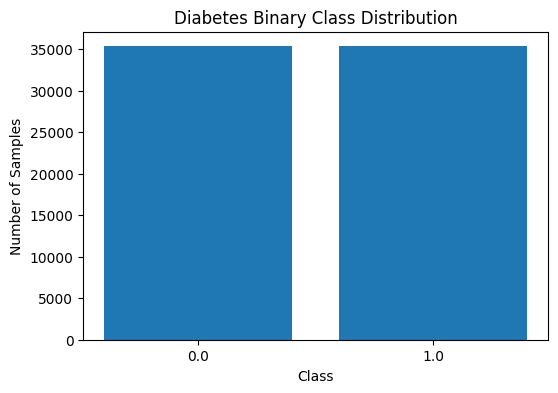

In [11]:
plt.figure(figsize=(6, 4))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.title("Diabetes Binary Class Distribution")

plt.show()

In [12]:
TARGET = "Diabetes_binary"

feature_names = df.drop(
    columns=[TARGET]
).columns.to_numpy()

X = (
    df
    .drop(columns=[TARGET])
    .to_numpy(dtype=np.float32)
)

y = (
    df[TARGET]
    .to_numpy(dtype=np.float32)
    .reshape(-1, 1)
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (70692, 21)
y shape: (70692, 1)


In [13]:
print(
    "First patient:",
    X[0]
)

print(
    "Target:",
    y[0]
)

First patient: [ 1.  0.  1. 26.  0.  0.  0.  1.  0.  1.  0.  1.  0.  3.  5. 30.  0.  1.
  4.  6.  8.]
Target: [0.]


In [14]:
def stratified_split(
    X,
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=42
):
    rng = np.random.default_rng(seed)

    y_flat = y.ravel()

    train_indices = []
    val_indices = []
    test_indices = []

    for cls in np.unique(y_flat):

        cls_indices = np.where(
            y_flat == cls
        )[0]

        rng.shuffle(cls_indices)

        n = len(cls_indices)

        n_train = int(
            train_ratio * n
        )

        n_val = int(
            val_ratio * n
        )

        train_indices.extend(
            cls_indices[:n_train]
        )

        val_indices.extend(
            cls_indices[
                n_train:n_train + n_val
            ]
        )

        test_indices.extend(
            cls_indices[
                n_train + n_val:
            ]
        )

    train_indices = np.array(train_indices)
    val_indices = np.array(val_indices)
    test_indices = np.array(test_indices)

    rng.shuffle(train_indices)
    rng.shuffle(val_indices)
    rng.shuffle(test_indices)

    return (
        X[train_indices],
        y[train_indices],

        X[val_indices],
        y[val_indices],

        X[test_indices],
        y[test_indices]
    )

(
    X_train,
    y_train,

    X_val,
    y_val,

    X_test,
    y_test

) = stratified_split(
    X,
    y,
    train_ratio=0.70,
    val_ratio=0.15,
    seed=SEED
)
print(
    "Train:",
    X_train.shape,
    y_train.shape
)

print(
    "Validation:",
    X_val.shape,
    y_val.shape
)

print(
    "Test:",
    X_test.shape,
    y_test.shape
)

Train: (49484, 21) (49484, 1)
Validation: (10602, 21) (10602, 1)
Test: (10606, 21) (10606, 1)


In [15]:
def show_class_ratio(name, y):

    values, counts = np.unique(
        y,
        return_counts=True
    )

    print(name)

    for value, count in zip(
        values,
        counts
    ):
        print(
            f"Class {int(value)}: "
            f"{count} "
            f"({count / len(y) * 100:.2f}%)"
        )

    print()
show_class_ratio(
    "Train",
    y_train
)

show_class_ratio(
    "Validation",
    y_val
)

show_class_ratio(
    "Test",
    y_test
)

Train
Class 0: 24742 (50.00%)
Class 1: 24742 (50.00%)

Validation
Class 0: 5301 (50.00%)
Class 1: 5301 (50.00%)

Test
Class 0: 5303 (50.00%)
Class 1: 5303 (50.00%)



In [16]:
# ============================================================
# EXPERIMENT 3 - FEATURE SELECTION
# Select Top 10 features based on correlation with target
# IMPORTANT: correlation is calculated ONLY on training data
# ============================================================

TOP_K = 10

y_train_flat = y_train.ravel()

correlations = []

for i in range(X_train.shape[1]):

    corr = np.corrcoef(
        X_train[:, i],
        y_train_flat
    )[0, 1]

    # Phòng trường hợp correlation bị NaN
    if np.isnan(corr):
        corr = 0.0

    correlations.append(corr)

correlations = np.array(correlations)

# Sắp xếp theo trị tuyệt đối của correlation
ranking = np.argsort(
    np.abs(correlations)
)[::-1]

print("Feature ranking based on training set:\n")

for rank, idx in enumerate(ranking, start=1):

    print(
        f"{rank:02d}. "
        f"{feature_names[idx]:25s} "
        f"Correlation = {correlations[idx]:.4f}"
    )

Feature ranking based on training set:

01. GenHlth                   Correlation = 0.4096
02. HighBP                    Correlation = 0.3827
03. HighChol                  Correlation = 0.2926
04. BMI                       Correlation = 0.2924
05. Age                       Correlation = 0.2798
06. DiffWalk                  Correlation = 0.2720
07. Income                    Correlation = -0.2271
08. HeartDiseaseorAttack      Correlation = 0.2131
09. PhysHlth                  Correlation = 0.2130
10. Education                 Correlation = -0.1720
11. PhysActivity              Correlation = -0.1590
12. Stroke                    Correlation = 0.1287
13. CholCheck                 Correlation = 0.1151
14. HvyAlcoholConsump         Correlation = -0.1001
15. MentHlth                  Correlation = 0.0910
16. Smoker                    Correlation = 0.0861
17. Veggies                   Correlation = -0.0769
18. Fruits                    Correlation = -0.0537
19. Sex                       Correl

In [17]:
selected_indices = ranking[:TOP_K]

selected_features = feature_names[
    selected_indices
]

print(f"\nTop {TOP_K} selected features:")

for i, name in enumerate(
    selected_features,
    start=1
):

    idx = selected_indices[i - 1]

    print(
        f"{i:02d}. "
        f"{name:25s} "
        f"| corr = {correlations[idx]:.4f}"
    )


Top 10 selected features:
01. GenHlth                   | corr = 0.4096
02. HighBP                    | corr = 0.3827
03. HighChol                  | corr = 0.2926
04. BMI                       | corr = 0.2924
05. Age                       | corr = 0.2798
06. DiffWalk                  | corr = 0.2720
07. Income                    | corr = -0.2271
08. HeartDiseaseorAttack      | corr = 0.2131
09. PhysHlth                  | corr = 0.2130
10. Education                 | corr = -0.1720


In [18]:
X_train = X_train[
    :,
    selected_indices
]

X_val = X_val[
    :,
    selected_indices
]

X_test = X_test[
    :,
    selected_indices
]

print(
    "Selected Train shape:",
    X_train.shape
)

print(
    "Selected Validation shape:",
    X_val.shape
)

print(
    "Selected Test shape:",
    X_test.shape
)

Selected Train shape: (49484, 10)
Selected Validation shape: (10602, 10)
Selected Test shape: (10606, 10)


In [19]:
mean = X_train.mean(
    axis=0,
    keepdims=True
)

std = X_train.std(
    axis=0,
    keepdims=True
)

std = np.where(
    std < 1e-8,
    1.0,
    std
)

X_train = (
    X_train - mean
) / std

X_val = (
    X_val - mean
) / std

X_test = (
    X_test - mean
) / std

In [20]:
print(
    "Training mean:",
    X_train.mean(axis=0)[:5]
)

print(
    "Training std:",
    X_train.std(axis=0)[:5]
)

Training mean: [ 5.0994711e-08 -3.1375428e-08  1.0407084e-09 -1.2549208e-07
  5.0898347e-08]
Training std: [1. 1. 1. 1. 1.]


In [21]:
def relu(x):
    return np.maximum(
        0,
        x
    )
def relu_derivative(x):
    return (
        x > 0
    ).astype(np.float32)

In [22]:
def sigmoid(x):

    x = np.clip(
        x,
        -50,
        50
    )

    return 1.0 / (
        1.0
        +
        np.exp(-x)
    )

In [23]:
def initialize_parameters(
    input_dim,
    hidden1=64,
    hidden2=32,
    output_dim=1,
    seed=42
):

    rng = np.random.default_rng(seed)

    W1 = (
        rng.standard_normal(
            (input_dim, hidden1)
        )
        * np.sqrt(
            2.0 / input_dim
        )
    ).astype(np.float32)

    b1 = np.zeros(
        (1, hidden1),
        dtype=np.float32
    )

    W2 = (
        rng.standard_normal(
            (hidden1, hidden2)
        )
        * np.sqrt(
            2.0 / hidden1
        )
    ).astype(np.float32)

    b2 = np.zeros(
        (1, hidden2),
        dtype=np.float32
    )

    W3 = (
        rng.standard_normal(
            (hidden2, output_dim)
        )
        * np.sqrt(
            2.0 / hidden2
        )
    ).astype(np.float32)

    b3 = np.zeros(
        (1, output_dim),
        dtype=np.float32
    )

    return {
        "W1": W1,
        "b1": b1,

        "W2": W2,
        "b2": b2,

        "W3": W3,
        "b3": b3
    }

params = initialize_parameters(
    input_dim=X_train.shape[1],
    hidden1=64,
    hidden2=32,
    output_dim=1,
    seed=SEED
)

In [24]:
for name, value in params.items():
    print(
        name,
        value.shape
    )

W1 (10, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 1)
b3 (1, 1)


In [25]:
def forward(
    X,
    params
):

    W1 = params["W1"]
    b1 = params["b1"]

    W2 = params["W2"]
    b2 = params["b2"]

    W3 = params["W3"]
    b3 = params["b3"]

    # Layer 1
    z1 = X @ W1 + b1
    h1 = relu(z1)

    # Layer 2
    z2 = h1 @ W2 + b2
    h2 = relu(z2)

    # Output layer
    z3 = h2 @ W3 + b3
    y_hat = sigmoid(z3)

    cache = {
        "X": X,

        "z1": z1,
        "h1": h1,

        "z2": z2,
        "h2": h2,

        "z3": z3,
        "y_hat": y_hat
    }

    return y_hat, cache

In [26]:
sample_X = X_train[:5]

sample_pred, sample_cache = forward(
    sample_X,
    params
)

print(
    "Prediction shape:",
    sample_pred.shape
)

print(
    sample_pred
)

Prediction shape: (5, 1)
[[0.47306925]
 [0.620315  ]
 [0.42580575]
 [0.6644349 ]
 [0.469682  ]]


In [27]:
def binary_cross_entropy(
    y,
    y_hat
):

    eps = 1e-8

    y_hat = np.clip(
        y_hat,
        eps,
        1 - eps
    )

    loss = -np.mean(
        y * np.log(y_hat)
        +
        (1 - y)
        * np.log(1 - y_hat)
    )

    return loss

In [28]:
sample_loss = binary_cross_entropy(
    y_train[:5],
    sample_pred
)

print(
    "Initial loss:",
    sample_loss
)

Initial loss: 0.7995864


In [29]:
def backward(
    y,
    cache,
    params
):

    X = cache["X"]

    z1 = cache["z1"]
    h1 = cache["h1"]

    z2 = cache["z2"]
    h2 = cache["h2"]

    y_hat = cache["y_hat"]

    W2 = params["W2"]
    W3 = params["W3"]

    n = len(X)

    # =========================
    # OUTPUT LAYER
    # =========================

    dz3 = (
        y_hat - y
    ) / n

    dW3 = (
        h2.T @ dz3
    )

    db3 = np.sum(
        dz3,
        axis=0,
        keepdims=True
    )

    # =========================
    # HIDDEN LAYER 2
    # =========================

    dh2 = (
        dz3 @ W3.T
    )

    dz2 = (
        dh2
        *
        relu_derivative(z2)
    )

    dW2 = (
        h1.T @ dz2
    )

    db2 = np.sum(
        dz2,
        axis=0,
        keepdims=True
    )

    # =========================
    # HIDDEN LAYER 1
    # =========================

    dh1 = (
        dz2 @ W2.T
    )

    dz1 = (
        dh1
        *
        relu_derivative(z1)
    )

    dW1 = (
        X.T @ dz1
    )

    db1 = np.sum(
        dz1,
        axis=0,
        keepdims=True
    )

    return {
        "W1": dW1,
        "b1": db1,

        "W2": dW2,
        "b2": db2,

        "W3": dW3,
        "b3": db3
    }

In [30]:
sample_gradients = backward(
    y_train[:5],
    sample_cache,
    params
)

for name, value in sample_gradients.items():

    print(
        name,
        value.shape
    )

W1 (10, 64)
b1 (1, 64)
W2 (64, 32)
b2 (1, 32)
W3 (32, 1)
b3 (1, 1)


In [31]:
def update_parameters(
    params,
    gradients,
    learning_rate
):

    for key in params:

        params[key] -= (
            learning_rate
            *
            gradients[key]
        )

In [32]:
def create_mini_batches(
    X,
    y,
    batch_size,
    rng
):

    indices = rng.permutation(
        len(X)
    )

    for start in range(
        0,
        len(X),
        batch_size
    ):

        batch_indices = indices[
            start:
            start + batch_size
        ]

        yield (
            X[batch_indices],
            y[batch_indices]
        )

In [33]:
# learning_rate = 0.001 #exp1
learning_rate = 0.01 #exp2, exp3
epochs = 50
batch_size = 512

rng = np.random.default_rng(
    SEED
)

train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    batch_losses = []

    for X_batch, y_batch in create_mini_batches(
        X_train,
        y_train,
        batch_size,
        rng
    ):

        # =====================
        # 1. FORWARD
        # =====================

        y_hat, cache = forward(
            X_batch,
            params
        )

        # =====================
        # 2. LOSS
        # =====================

        loss = binary_cross_entropy(
            y_batch,
            y_hat
        )

        batch_losses.append(
            loss
        )

        # =====================
        # 3. BACKWARD
        # =====================

        gradients = backward(
            y_batch,
            cache,
            params
        )

        # =====================
        # 4. UPDATE
        # =====================

        update_parameters(
            params,
            gradients,
            learning_rate
        )

    # =========================
    # TRAIN LOSS
    # =========================

    train_loss = np.mean(
        batch_losses
    )

    # =========================
    # VALIDATION LOSS
    # =========================

    val_pred, _ = forward(
        X_val,
        params
    )

    val_loss = binary_cross_entropy(
        y_val,
        val_pred
    )

    train_loss_history.append(
        train_loss
    )

    val_loss_history.append(
        val_loss
    )

    print(
        f"Epoch {epoch + 1:02d}/{epochs} | "
        f"Train Loss = {train_loss:.4f} | "
        f"Val Loss = {val_loss:.4f}"
    )

Epoch 01/50 | Train Loss = 0.6572 | Val Loss = 0.6030
Epoch 02/50 | Train Loss = 0.5822 | Val Loss = 0.5744
Epoch 03/50 | Train Loss = 0.5619 | Val Loss = 0.5608
Epoch 04/50 | Train Loss = 0.5504 | Val Loss = 0.5523
Epoch 05/50 | Train Loss = 0.5431 | Val Loss = 0.5464
Epoch 06/50 | Train Loss = 0.5375 | Val Loss = 0.5418
Epoch 07/50 | Train Loss = 0.5332 | Val Loss = 0.5384
Epoch 08/50 | Train Loss = 0.5298 | Val Loss = 0.5357
Epoch 09/50 | Train Loss = 0.5271 | Val Loss = 0.5335
Epoch 10/50 | Train Loss = 0.5249 | Val Loss = 0.5317
Epoch 11/50 | Train Loss = 0.5234 | Val Loss = 0.5301
Epoch 12/50 | Train Loss = 0.5218 | Val Loss = 0.5289
Epoch 13/50 | Train Loss = 0.5205 | Val Loss = 0.5278
Epoch 14/50 | Train Loss = 0.5192 | Val Loss = 0.5269
Epoch 15/50 | Train Loss = 0.5183 | Val Loss = 0.5261
Epoch 16/50 | Train Loss = 0.5173 | Val Loss = 0.5253
Epoch 17/50 | Train Loss = 0.5166 | Val Loss = 0.5246
Epoch 18/50 | Train Loss = 0.5157 | Val Loss = 0.5241
Epoch 19/50 | Train Loss = 0

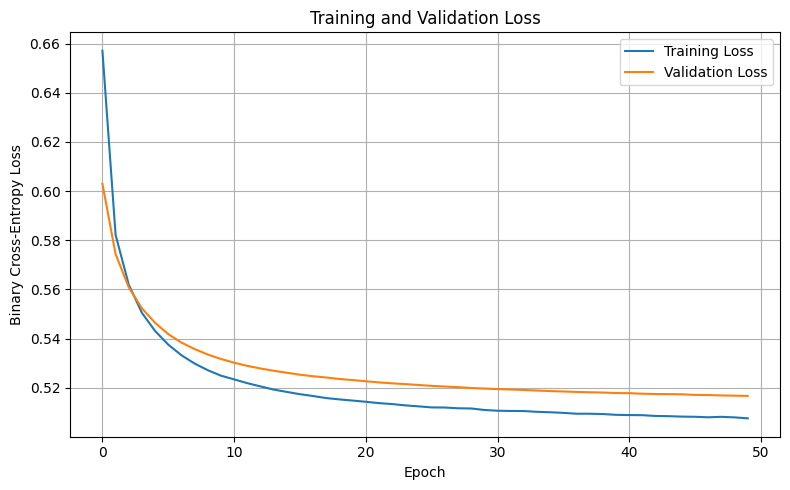

In [34]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    train_loss_history,
    label="Training Loss"
)

plt.plot(
    val_loss_history,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Binary Cross-Entropy Loss")

plt.title(
    "Training and Validation Loss"
)

plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "loss_curve-exp3.png",
    dpi=150
)

plt.show()

In [35]:
test_prob, _ = forward(
    X_test,
    params
)

y_pred = (
    test_prob >= 0.5
).astype(np.float32)

In [36]:
accuracy = np.mean(
    y_pred == y_test
)

print(
    f"Accuracy: {accuracy:.4f}"
)

Accuracy: 0.7434


In [37]:
TP = np.sum(
    (y_pred == 1)
    &
    (y_test == 1)
)

TN = np.sum(
    (y_pred == 0)
    &
    (y_test == 0)
)

FP = np.sum(
    (y_pred == 1)
    &
    (y_test == 0)
)

FN = np.sum(
    (y_pred == 0)
    &
    (y_test == 1)
)

print("TP:", TP)
print("TN:", TN)
print("FP:", FP)
print("FN:", FN)

TP: 4161
TN: 3724
FP: 1579
FN: 1142


In [38]:
eps = 1e-8

precision = (
    TP /
    (TP + FP + eps)
)

recall = (
    TP /
    (TP + FN + eps)
)

f1 = (
    2
    * precision
    * recall
    /
    (
        precision
        +
        recall
        +
        eps
    )
)

print(
    f"Accuracy : {accuracy:.4f}"
)

print(
    f"Precision: {precision:.4f}"
)

print(
    f"Recall   : {recall:.4f}"
)

print(
    f"F1-score : {f1:.4f}"
)

Accuracy : 0.7434
Precision: 0.7249
Recall   : 0.7847
F1-score : 0.7536


In [39]:
confusion_matrix = np.array(
    [
        [TN, FP],
        [FN, TP]
    ]
)

print(
    confusion_matrix
)

[[3724 1579]
 [1142 4161]]


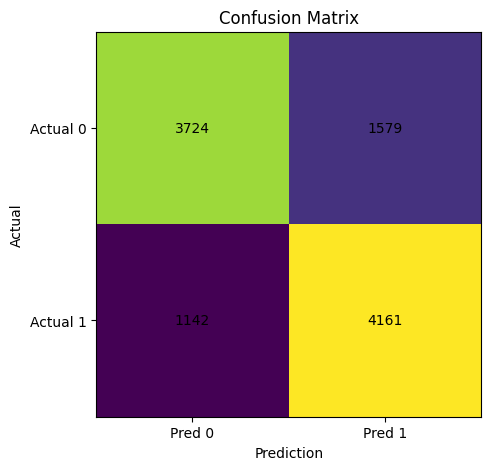

In [40]:
plt.figure(
    figsize=(5, 5)
)

plt.imshow(
    confusion_matrix
)

plt.xticks(
    [0, 1],
    ["Pred 0", "Pred 1"]
)

plt.yticks(
    [0, 1],
    ["Actual 0", "Actual 1"]
)

plt.xlabel("Prediction")
plt.ylabel("Actual")

plt.title(
    "Confusion Matrix"
)

for i in range(2):

    for j in range(2):

        plt.text(
            j,
            i,
            confusion_matrix[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "confusion_matrix-exp3.png",
    dpi=150
)

plt.show()

In [41]:
for i in range(10):

    print(
        f"Patient {i + 1:02d} | "
        f"Probability = {test_prob[i, 0]:.4f} | "
        f"Prediction = {int(y_pred[i, 0])} | "
        f"Actual = {int(y_test[i, 0])}"
    )

Patient 01 | Probability = 0.8040 | Prediction = 1 | Actual = 1
Patient 02 | Probability = 0.7690 | Prediction = 1 | Actual = 1
Patient 03 | Probability = 0.8347 | Prediction = 1 | Actual = 1
Patient 04 | Probability = 0.7343 | Prediction = 1 | Actual = 1
Patient 05 | Probability = 0.8964 | Prediction = 1 | Actual = 1
Patient 06 | Probability = 0.0975 | Prediction = 0 | Actual = 0
Patient 07 | Probability = 0.1780 | Prediction = 0 | Actual = 0
Patient 08 | Probability = 0.0387 | Prediction = 0 | Actual = 0
Patient 09 | Probability = 0.6771 | Prediction = 1 | Actual = 0
Patient 10 | Probability = 0.4242 | Prediction = 0 | Actual = 0


In [42]:
_, representation_cache = forward(
    X_test,
    params
)

H1 = representation_cache["h1"]
H2 = representation_cache["h2"]

print(
    "Original representation:",
    X_test.shape
)

print(
    "Hidden representation H1:",
    H1.shape
)

print(
    "Hidden representation H2:",
    H2.shape
)

Original representation: (10606, 10)
Hidden representation H1: (10606, 64)
Hidden representation H2: (10606, 32)


In [47]:
MODEL_PATH = (
    MODEL_DIR
    /
    "diabetes_numpy_mlp-exp3.npz"
)

selected_features_to_save = np.asarray(
    selected_features,
    dtype=str
)

np.savez(
    MODEL_PATH,

    W1=params["W1"],
    b1=params["b1"],

    W2=params["W2"],
    b2=params["b2"],

    W3=params["W3"],
    b3=params["b3"],

    mean=mean,
    std=std,
    
    selected_indices=selected_indices,
    selected_features=selected_features,

    threshold=np.array([0.5])
)

print(
    "Saved:",
    MODEL_PATH
)

Saved: models\diabetes_numpy_mlp-exp3.npz


In [49]:
saved = np.load(
    MODEL_PATH
    , 
    allow_pickle=True
)

loaded_params = {
    "W1": saved["W1"],
    "b1": saved["b1"],

    "W2": saved["W2"],
    "b2": saved["b2"],

    "W3": saved["W3"],
    "b3": saved["b3"]
}

loaded_mean = saved["mean"]
loaded_std = saved["std"]

loaded_selected_indices = saved[
    "selected_indices"
]

loaded_selected_features = saved[
    "selected_features"
]

print(
    "Selected features:"
)

print(
    loaded_selected_features
)

print(
    "Model loaded successfully."
)

Selected features:
['GenHlth' 'HighBP' 'HighChol' 'BMI' 'Age' 'DiffWalk' 'Income'
 'HeartDiseaseorAttack' 'PhysHlth' 'Education']
Model loaded successfully.


In [50]:
def predict_new_patient(
    raw_features,
    params,
    mean,
    std,
    selected_indices,
    threshold=0.5
):

    # 21 features ban đầu
    x = np.asarray(
        raw_features,
        dtype=np.float32
    ).reshape(1, -1)

    # Chỉ lấy 10 feature Exp 3 sử dụng
    x = x[
        :,
        selected_indices
    ]

    # Normalize 10 features
    x_scaled = (
        x - mean
    ) / std

    probability, _ = forward(
        x_scaled,
        params
    )

    probability = float(
        probability[0, 0]
    )

    prediction = int(
        probability >= threshold
    )

    return (
        probability,
        prediction
    )

In [ ]:
# probability, prediction = predict_new_patient(
#     raw_features,
#     loaded_params,
#     loaded_mean,
#     loaded_std,
#     loaded_selected_indices
# )